# Analyse stimulus history of EW2 recordings

Requires information from stimulus log file and recording field positions from `.smh`header files; for this specific analysis, the data is already consolidated in a `.cvs`file (see below).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, time 
from pathlib import Path
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import numpy as np

import stim_outlines
import stim_movies

In [3]:
CONSOL_PATH = Path("../data/experiment-overview_consolidated.csv")
STIM_MOV_PATH = Path("../data/stimuli-as-movies")
STIM_MOV_EXT = ".pickle" 

## Generate a map of the stimulus presentation


**(1) Area illuminated by the different stimuli**

Get illuminated area and mean illumination for the stimuli.   
Note that it would be better to get the parameters directly from `stims`, but here we just use the most important stimulus parameters for an estimate.


In [4]:
# Approx. field of view of stimulus through objective lens
# ESTIMATED: CHECK!
#FOV_diam = 1500  # Nikon 16x objective (CF175 LWD×16/0.8W, DIC N2)
FOV_diam = 1000   # W Plan-Apochromat 20x/1,0 DIC M27, Zeiss

# Create shapes (=areas illuminated by the stimuli)
MovingBar = dict(
    {'barDx_um': 1000.0, 
     'barDy_um': 300.0, 
     'nTrials': 3, 
     'vel_umSec': 1000.0, 
     'tMoveDur_s': 4.0, 
     'DirList': [0, 180, 45, 225, 90, 270, 135, 315], 
     'barColor': (255, 255, 255), 
     'bkgColor': (0, 0, 0)}
)
lEdge = MovingBar["barDy_um"]
trajLen = MovingBar["tMoveDur_s"] *MovingBar["vel_umSec"] +MovingBar["barDx_um"]
mb = stim_outlines.movingBar(lEdge, trajLen, MovingBar["DirList"], FOV_diam=FOV_diam)

RGC_Chirp = dict(
    {'tSteadyON_s': 3.0, 
     'tSteadyOFF2_s': 2.0, 
     'tSteadyMID_s': 2.0, 
     'chirpMaxFreq_Hz': 8.0, 
     'tSteadyOFF_s': 3.0, 
     'ContrastFreq_Hz': 2.0, 
     'nTrials': 5, 
     'dxStim_um': 1000, 
     'IHalf': 127, 
     'chirpDur_s': 8.0, 
     'IFull': 254}
)
chirp = stim_outlines.spot(diam=RGC_Chirp["dxStim_um"], FOV_diam=FOV_diam)

MouseCam_Left = dict(
    {'movparams_Train': {'nFr': 16200, 'dyFr': 56, 'dxFr': 56}, 
     'movName_Train': '//Katrin//RGCs//train_images_right.jpg', 
     'nFrRepeats': 2, 
     'movparams_Test': {'nFr': 750, 'dyFr': 56, 'dxFr': 56}, 
     'FrameRateMovie': 30.0, 
     'movName_Test': '//Katrin//RGCs//test_images_rand_right.jpg', 
     'movScale': (12.5, 12.5), 
     'movAlpha': 255, 
     'movOrient': 0, 
     'nFrPerMarker': 3, 
     'IndexName': 'RandomSequences', 
     'nTrials': 1, 
     'durSnippet_s': 5.0}
)
dx = MouseCam_Left["movparams_Train"]["dxFr"] *MouseCam_Left["movScale"][0]
dy = MouseCam_Left["movparams_Train"]["dyFr"] *MouseCam_Left["movScale"][1]
mouseMovie = stim_outlines.box(dx, dy, FOV_diam=FOV_diam)


**(2) Get stimulus sequence and recording positions**

Load currated file with stimulus and recording data.

Bringing together the data from the `.smh` files and the stimulus log file automatically is currently tricky, as the data here was recorded on two PCs with not well synchronized clocks. This needs to be done (e.g., sync time to time server automatically) in future experiments. Also, it would be good to record the scan position in the QDSpy `.log` file to have the field positions also for focus scans (where no recording file is written).


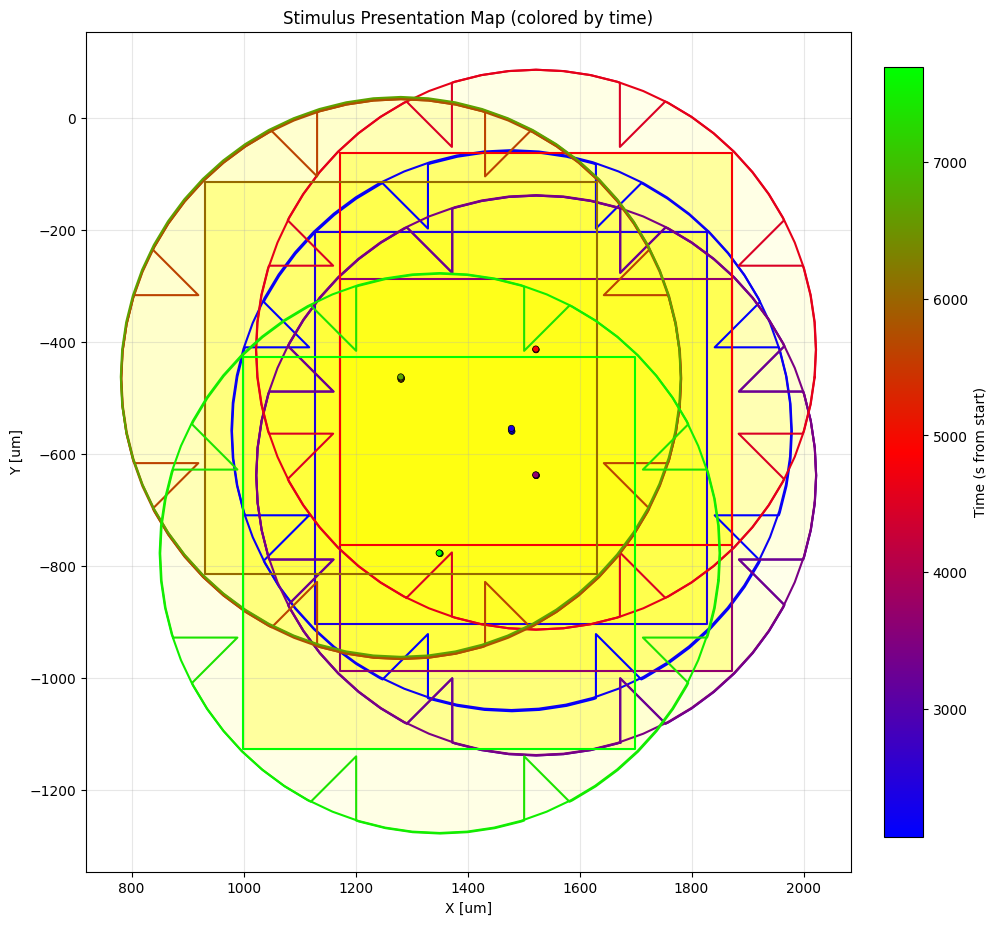

In [5]:
df = pd.read_csv(CONSOL_PATH, on_bad_lines='warn', sep=';')

# Create figure for plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Get time range for colormap normalization (only for rows with position data)
df_with_pos = df[df['pos_xyz'].notna()].copy()
if len(df_with_pos) > 0:
    t_min = df_with_pos['t_abs_s'].min()
    t_max = df_with_pos['t_abs_s'].max()
else:
    t_min, t_max = 0, 1

# Create colormap (using 'brg' - blue-red-green)
norm = Normalize(vmin=t_min, vmax=t_max)
cmap = cm.brg

# The alpha value equivalent to 1 sec stimulus exposure
alpha_per_s = 0.001

for index, row in df.iterrows():
    # Get coordinates 
    if row["pos_xyz"] is not np.nan:
        s = row["pos_xyz"][1:-1].split(",")
        pos_xyz = [float(s[i]) for i in range(len(s))]
    else:
        pos_xyz = None    

    # Get other parameters
    fStimName = row["stimFileName"]
    fRecName = "" if row["dataFileName"] is np.nan else row["dataFileName"]
    t_abs_s = row["t_abs_s"]
    t_dur_s = row["t_dur_s"]
    '''
    print(f"{row["index"]:3d} {fStimName:32s} {fRecName:30s} {pos_xyz}")
    '''

    if pos_xyz:
        # Plot stimuli only for presentations w/ position data
        x0, y0 = pos_xyz[0], pos_xyz[1]
        
        # Get color based on time
        edge_color = cmap(norm(t_abs_s))
        
        if fStimName.upper() in ["DS"]:
            # Plot moving bar outline at the current position
            poly = stim_outlines.movingBar(lEdge, trajLen, MovingBar["DirList"], x0=x0, y0=y0, FOV_diam=FOV_diam)
            x, y = poly.exterior.xy

            # Adjusting exposure to presentation duration and mean intensity (estimate)
            # TODO: Better estimate
            expos = min(1, t_dur_s *alpha_per_s *0.2)
            
            # Fill first (lower z-order), outline on top (higher z-order)
            ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
            ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

        elif fStimName in ["Chirp"]:
            # Plot chirp outline at the current position
            poly = stim_outlines.spot(diam=RGC_Chirp["dxStim_um"], x0=x0, y0=y0, FOV_diam=FOV_diam)
            x, y = poly.exterior.xy

            # Adjusting exposure to presentation duration and mean intensity (estimate)
            # TODO: Better estimate
            expos = min(1, t_dur_s *alpha_per_s *0.5)
            
            # Fill first (lower z-order), outline on top (higher z-order)
            ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
            ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

        elif fStimName in ["MouseCam_Right"]:
            # Plot movie outline at the current position
            poly = stim_outlines.box(dx, dy, x0=x0, y0=y0, FOV_diam=FOV_diam)
            x, y = poly.exterior.xy

            # Adjusting exposure to presentation duration and mean intensity (estimate)
            # TODO: Better estimate
            expos = min(1, t_dur_s *alpha_per_s *0.5)
            
            # Fill first (lower z-order), outline on top (higher z-order)
            ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
            ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

# Add scatter points for recording positions
df_valid = df[df['pos_xyz'].notna()].copy()
df_valid['x'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[0]))
df_valid['y'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[1]))
sc = ax.scatter(df_valid['x'], df_valid['y'], c=df_valid['t_abs_s'], cmap='brg', 
                s=20, marker='o', zorder=10, edgecolor='k', linewidth=0.5)

# Add colorbar with same height as the plot
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Time (s from start)')

ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
ax.set_title('Stimulus Presentation Map (colored by time)')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Generate a map of the stimulus presentation (using movies)

### Load stimulus movie files into numpy array

... and zero blue channel, as it was not used (green=G, red=UV?)

In [6]:
# Load movie files and zero blue channel
tmp_path = Path.joinpath(STIM_MOV_PATH, "RGC_MovingBar" +STIM_MOV_EXT)
mov_DS = stim_movies.load_qdspy_movie(tmp_path)
mov_DS[:,:,:,2] = 0

tmp_path = Path.joinpath(STIM_MOV_PATH, "RGC_Chirp" +STIM_MOV_EXT)
mov_Chirp = stim_movies.load_qdspy_movie(tmp_path)
mov_Chirp[:,:,:,2] = 0

tmp_path = Path.joinpath(STIM_MOV_PATH, "MouseCam_Left" +STIM_MOV_EXT)
mov_MouseCamLeft = stim_movies.load_qdspy_movie(tmp_path)
mov_MouseCamLeft[:,:,:,2] = 0

# Define spatial and temporal scaling (approximated, see TODOs)
# (pixel size from moving bar width / bar pixels in movies)
_, dx, dy, _ = mov_DS.shape
px_um = 300 /7
params = dict({
    "pix_size_um": 300 /7,  # moving bar width / bar pixels in movies
    "mov_dxy": [dx, dy],
    "mov_dxy_um": [px_um *dx, px_um *dy],
    "dt_fr_s": 1 /60,
    "nCh": 2
})

Loading pickle file from: ..\data\stimuli-as-movies\RGC_MovingBar.pickle
Done.
Loading pickle file from: ..\data\stimuli-as-movies\RGC_Chirp.pickle
Done.
Loading pickle file from: ..\data\stimuli-as-movies\MouseCam_Left.pickle
Done.


Accumulator image size: 40 x 35 pixels
Spatial extent: X=[500.0, 2250.0] um, Y=[-1250.0, 250.0] um


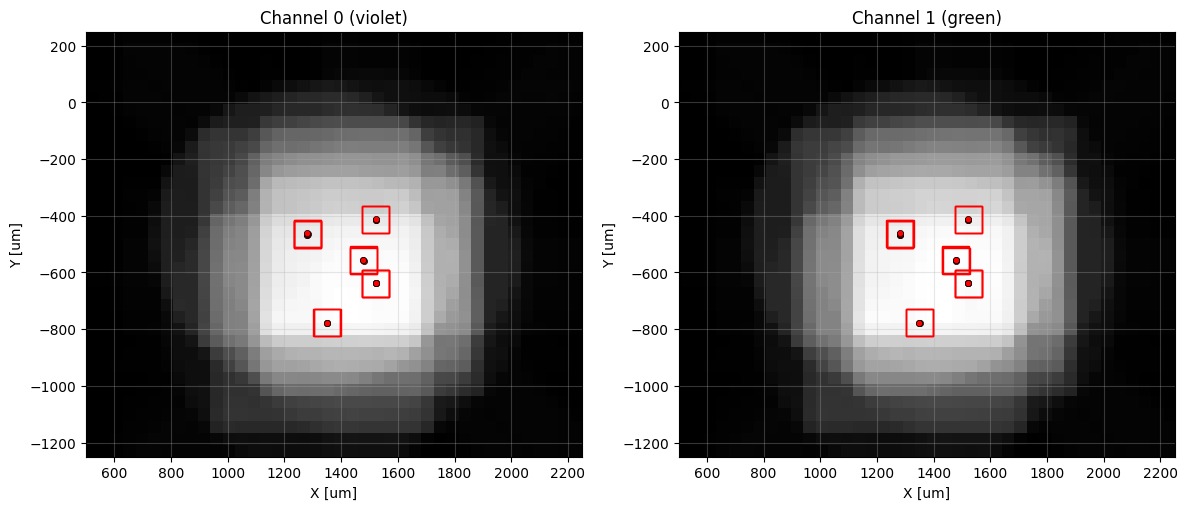

In [9]:
# Read consolidated experiment protocol
df = pd.read_csv(CONSOL_PATH, on_bad_lines='warn', sep=';')

# Recording field size and factor by which to increase recording field area
# for intensity exposure traces
rec_field_dxy_um = [95, 95]
surr_factor = 1.0    

# Determine the extent of the experiment area to create accumulator array
df_valid = df[df['pos_xyz'].notna()].copy()
df_valid['x'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[0]))
df_valid['y'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[1]))

# Set fixed bounds for the display area
x_min = 500
x_max = 2250
y_min = -1250
y_max = 250

# Create accumulator array for the summary picture
pix_size_um = params["pix_size_um"]
acc_width_px = int((x_max - x_min) / pix_size_um)
acc_height_px = int((y_max - y_min) / pix_size_um)
acc_image = np.zeros((acc_height_px, acc_width_px, params["nCh"]), dtype=np.float64)

print(f"Accumulator image size: {acc_width_px} x {acc_height_px} pixels")
print(f"Spatial extent: X=[{x_min:.1f}, {x_max:.1f}] um, Y=[{y_min:.1f}, {y_max:.1f}] um")

for index, row in df.iterrows():
    # Get coordinates 
    if row["pos_xyz"] is not np.nan:
        s = row["pos_xyz"][1:-1].split(",")
        pos_xyz = [float(s[i]) for i in range(len(s))]
    else:
        pos_xyz = None    

    # Get other parameters
    fStimName = row["stimFileName"]
    fRecName = "" if row["dataFileName"] is np.nan else row["dataFileName"]
    t_abs_s = row["t_abs_s"]
    t_dur_s = row["t_dur_s"]

    if pos_xyz:
        # Consider only stimuli w/ position data
        x0, y0 = pos_xyz[0], pos_xyz[1]

        # Generate flattened stimulus movie and add it to the exposure picture
        if fStimName.upper() in ["DS"]:
            _mov = mov_DS
        elif fStimName.upper() in ["CHIRP"]:
            _mov = mov_Chirp
        elif fStimName.upper() in ["MOUSECAM_RIGHT"]:
            _mov = mov_MouseCamLeft
        else:
            continue
            
        mov_flat = stim_movies.flatten_movie(_mov, params, _range_s=[0, t_dur_s])
        
        # Ensure the movie has the correct number of channels
        mov_h, mov_w, mov_ch = mov_flat.shape
        if mov_ch != params["nCh"]:
            # Take only the first nCh channels
            mov_flat = mov_flat[:, :, :params["nCh"]]
        
        # Calculate position in accumulator array
        # Movie center is at (x0, y0), movie origin is at top-left
        mov_h, mov_w, _ = mov_flat.shape
        mov_center_x_um = x0
        mov_center_y_um = y0
        
        # Convert to pixel coordinates in accumulator
        # Note: Image coordinates have origin at top-left, so we need to flip y
        acc_center_x_px = int((mov_center_x_um - x_min) / pix_size_um)
        acc_center_y_px = int((mov_center_y_um - y_min) / pix_size_um)
        
        # Calculate bounds for placing the movie
        acc_x0 = acc_center_x_px - mov_w // 2
        acc_x1 = acc_x0 + mov_w
        acc_y0 = acc_center_y_px - mov_h // 2
        acc_y1 = acc_y0 + mov_h
        
        # Clip to accumulator bounds and add
        mov_x0 = max(0, -acc_x0)
        mov_x1 = mov_w - max(0, acc_x1 - acc_width_px)
        mov_y0 = max(0, -acc_y0)
        mov_y1 = mov_h - max(0, acc_y1 - acc_height_px)
        
        acc_x0_clip = max(0, acc_x0)
        acc_x1_clip = min(acc_width_px, acc_x1)
        acc_y0_clip = max(0, acc_y0)
        acc_y1_clip = min(acc_height_px, acc_y1)
        
        # Add the flattened movie to accumulator
        acc_image[acc_y0_clip:acc_y1_clip, acc_x0_clip:acc_x1_clip, :] += \
            mov_flat[mov_y0:mov_y1, mov_x0:mov_x1, :]

# Normalize the accumulated image for display
acc_image_norm = acc_image / (acc_image.max() + 1e-10)

# Create figure for plotting
fig, axes = plt.subplots(1, params["nCh"], figsize=(12, 6))
if params["nCh"] == 1:
    axes = [axes]

colors = ['violet', 'green', 'blue']
for ch in range(params["nCh"]):
    im = axes[ch].imshow(acc_image_norm[:, :, ch], cmap='gray', 
                         extent=[x_min, x_max, y_max, y_min], 
                         origin='upper', aspect='equal')
    axes[ch].set_xlabel('X [um]')
    axes[ch].set_ylabel('Y [um]')
    axes[ch].set_title(f'Channel {ch} ({colors[ch]})')
    axes[ch].set_xlim(x_min, x_max)
    axes[ch].set_ylim(y_min, y_max)
    
    # Draw gray rectangles centered at recording positions
    from matplotlib.patches import Rectangle
    rec_size = rec_field_dxy_um[0]
    for _, row_data in df_valid.iterrows():
        rect = Rectangle((row_data['x'] - rec_size/2, row_data['y'] - rec_size/2),
                         rec_size, rec_size,
                         linewidth=1, edgecolor='red', facecolor='none', zorder=9)
        axes[ch].add_patch(rect)
    
    # Add scatter points for recording positions
    axes[ch].scatter(df_valid['x'], df_valid['y'], c='red', 
                    s=20, marker='o', zorder=10, edgecolor='k', linewidth=0.5)
    
    axes[ch].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()